# ORT: Quantum Mechanical Connection

**Chapter 13 | §13.1–13.8 | Formulas 104–113**

This notebook explores the correspondence between the Being-vector of ORT
and the fundamental quantities of quantum mechanics.

> **Note**: these are *correspondences*, not a derivation of QM from ORT.
> ORT shows that its structure naturally contains the quantities that
> appear as conjugate pairs in quantum mechanics.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent / 'shared'))
from ort_core import (C, ORT,
                            H_PLANCK, HBAR, M_ELECTRON, M_PROTON)
from ort_plots import (zijn_qm_diagram, de_broglie_plot,
                             zijn_vector_diagram)
import numpy as np
import math

---
## §13.1 — The Being-vector as bridge

The Being-vector (formulas 16–17) has two components:

$$S_{space} = p = m_0 c \tan\theta \quad (104)$$
$$S_{time} = m_0 c \quad (105)$$

The spatial component is the momentum $p$; the time component is the rest mass times the speed of light.
These are precisely the quantities that appear as **conjugate pairs** in quantum mechanics:

- $x \leftrightarrow p = S_{space}$ (position-momentum)
- $t \leftrightarrow E = S_{time} \cdot c = m_0 c^2$ (time-energy)

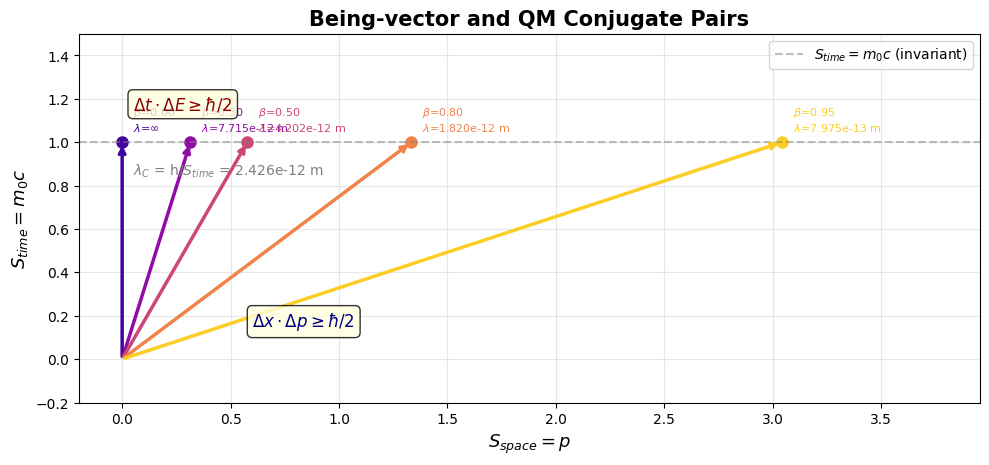

In [2]:
# Being-vector with QM correspondence
zijn_qm_diagram(m0=M_ELECTRON, lang='en')
pass

In [3]:
# Numerical verification: Being-components for an electron
print("=== Being-vector components (electron) ===")
print(f"Rest mass m₀ = {M_ELECTRON:.4e} kg")
print(f"S_time = m₀c = {M_ELECTRON * C:.4e} kg·m/s")
print()

for beta in [0.0, 0.1, 0.5, 0.9, 0.99]:
    stv = ORT.from_beta(beta)
    p = stv.momentum(M_ELECTRON)
    E = stv.total_energy(M_ELECTRON)
    theta = stv.theta_degrees
    print(f"β={beta:.2f}  θ={theta:6.2f}°  S_space(=p)={p:.4e}  E=S·c={E:.4e} J")

=== Being-vector components (electron) ===
Rest mass m₀ = 9.1094e-31 kg
S_time = m₀c = 2.7309e-22 kg·m/s

β=0.00  θ=  0.00°  S_space(=p)=0.0000e+00  E=S·c=8.1871e-14 J
β=0.10  θ=  5.74°  S_space(=p)=2.7447e-23  E=S·c=8.2284e-14 J
β=0.50  θ= 30.00°  S_space(=p)=1.5767e-22  E=S·c=9.4537e-14 J
β=0.90  θ= 64.16°  S_space(=p)=5.6387e-22  E=S·c=1.8783e-13 J
β=0.99  θ= 81.89°  S_space(=p)=1.9165e-21  E=S·c=5.8037e-13 J


---
## §13.2 — Uncertainty relations

The Heisenberg uncertainty relations connect precisely the quantities
that appear in the Being-vector:

$$\Delta x \cdot \Delta p \geq \hbar/2 \quad (106)$$
$$\Delta t \cdot \Delta E \geq \hbar/2 \quad (107)$$

- Equation (106) couples position $x$ to momentum $p = S_{space}$.
- Equation (107) couples time $t$ to energy $E$, related to the Being-vector via $E = |\vec{S}| \cdot c$.

The uncertainty relations are thus the **quantum limits** on the accuracy
with which the components of the Being-vector can be determined.

In [4]:
# Uncertainty relations: minimum uncertainties
print("=== Uncertainty Relations ===")
print(f"ℏ = {HBAR:.4e} J·s")
print(f"ℏ/2 = {HBAR/2:.4e} J·s")
print()

# Example: electron confined in an atom (Δx ≈ 1 Å)
delta_x = 1e-10  # 1 Ångström
delta_p_min = HBAR / (2 * delta_x)
print(f"Electron in atom (Δx ≈ {delta_x:.0e} m):")
print(f"  Minimum Δp ≥ {delta_p_min:.4e} kg·m/s")
print(f"  For comparison: S_space(β=0.01) = {ORT.from_beta(0.01).momentum(M_ELECTRON):.4e} kg·m/s")
print()

# Time-energy: Δt for a photon with E = m_e c²
E_rest = M_ELECTRON * C**2
delta_t_min = HBAR / (2 * E_rest)
print(f"Rest energy electron E₀ = {E_rest:.4e} J = {E_rest / 1.602e-19:.1f} eV")
print(f"  Minimum Δt ≥ {delta_t_min:.4e} s")

=== Uncertainty Relations ===
ℏ = 1.0546e-34 J·s
ℏ/2 = 5.2729e-35 J·s

Electron in atom (Δx ≈ 1e-10 m):
  Minimum Δp ≥ 5.2729e-25 kg·m/s
  For comparison: S_space(β=0.01) = 2.7311e-24 kg·m/s

Rest energy electron E₀ = 8.1871e-14 J = 511055.3 eV
  Minimum Δt ≥ 6.4404e-22 s


---
## §13.3 — De Broglie wavelength

De Broglie (1924) associated a wavelength with every particle momentum:

$$\lambda = \frac{h}{p} = \frac{h}{S_{space}} \quad (108)$$

In ORT terms: the wave property of matter is directly coupled to the
**spatial component** of the Being-vector. The larger $S_{space}$ (more
momentum, thus larger angle $\theta$), the shorter the wavelength.

In [5]:
# De Broglie wavelength for an electron at various speeds
print("=== De Broglie wavelength (electron) ===")
print(f"  h = {H_PLANCK:.4e} J·s")
print()

lambda_C = ORT.compton_wavelength(M_ELECTRON)
print(f"{'\u03b2':>6}  {'\u03b8':>8}  {'\u03bb_dB':>12}  {'\u03bb_dB/\u03bb_C':>10}")
for beta in [0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 0.999]:
    stv = ORT.from_beta(beta)
    lam = stv.de_broglie_wavelength(M_ELECTRON)
    print(f"{beta:6.3f}  {stv.theta_degrees:8.3f}°  {lam:12.4e} m  {lam/lambda_C:10.2f}")

=== De Broglie wavelength (electron) ===
  h = 6.6261e-34 J·s

     β         θ          λ_dB    λ_dB/λ_C
 0.001     0.057°    2.4263e-09 m     1000.00
 0.010     0.573°    2.4262e-10 m       99.99
 0.100     5.739°    2.4141e-11 m        9.95
 0.500    30.000°    4.2025e-12 m        1.73
 0.900    64.158°    1.1751e-12 m        0.48
 0.990    81.890°    3.4573e-13 m        0.14
 0.999    87.437°    1.0859e-13 m        0.04


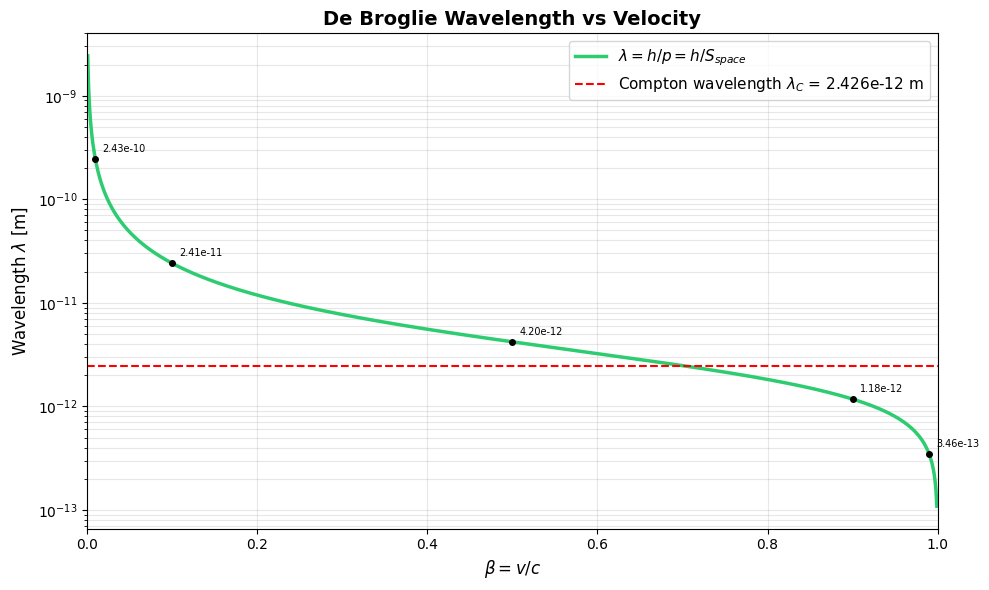

In [6]:
# De Broglie wavelength vs speed
de_broglie_plot(m0=M_ELECTRON, lang='en')
pass

---
## §13.4 — Planck-Einstein relation

The energy of a photon is coupled to its frequency:

$$E = hf \quad (109)$$

For a particle at rest ($\theta = 0$, $E = m_0 c^2$) this defines
the **Compton frequency**:

$$f_0 = \frac{m_0 c^2}{h} \quad (110)$$

This is the "tick frequency" of the particle at rest — the frequency
associated with the time component of the Being-vector.

In [7]:
# Compton frequency
print("=== Compton frequency (tick frequency at rest) ===")
print()

for name, m0 in [("Electron", M_ELECTRON), ("Proton", M_PROTON)]:
    f0 = ORT.compton_frequency(m0)
    E0 = m0 * C**2
    print(f"{name}:")
    print(f"  m₀ = {m0:.4e} kg")
    print(f"  E₀ = m₀c² = {E0:.4e} J = {E0/1.602e-19:.0f} eV")
    print(f"  f₀ = m₀c²/h = {f0:.4e} Hz")
    print()

# Relativistic frequency: f = f₀/cosθ
print("Relativistic frequency electron:")
for beta in [0.0, 0.5, 0.9, 0.99]:
    stv = ORT.from_beta(beta)
    f = stv.particle_frequency(M_ELECTRON)
    f0 = ORT.compton_frequency(M_ELECTRON)
    print(f"  β={beta:.2f}  θ={stv.theta_degrees:6.2f}°  f = {f:.4e} Hz  (f/f₀ = {f/f0:.4f} = 1/cosθ)")

=== Compton frequency (tick frequency at rest) ===

Electron:
  m₀ = 9.1094e-31 kg
  E₀ = m₀c² = 8.1871e-14 J = 511055 eV
  f₀ = m₀c²/h = 1.2356e+20 Hz

Proton:
  m₀ = 1.6726e-27 kg
  E₀ = m₀c² = 1.5033e-10 J = 938375541 eV
  f₀ = m₀c²/h = 2.2687e+23 Hz

Relativistic frequency electron:
  β=0.00  θ=  0.00°  f = 1.2356e+20 Hz  (f/f₀ = 1.0000 = 1/cosθ)
  β=0.50  θ= 30.00°  f = 1.4267e+20 Hz  (f/f₀ = 1.1547 = 1/cosθ)
  β=0.90  θ= 64.16°  f = 2.8346e+20 Hz  (f/f₀ = 2.2942 = 1/cosθ)
  β=0.99  θ= 81.89°  f = 8.7589e+20 Hz  (f/f₀ = 7.0888 = 1/cosθ)


---
## §13.5 — Compton wavelength

The Compton wavelength is the spatial equivalent of the Compton frequency:

$$\lambda_C = \frac{h}{m_0 c} = \frac{h}{S_{time}} \quad (111)$$

This is the fundamental length scale below which quantum field effects
become important for a particle with mass $m_0$.

The Compton wavelength is directly the ratio of Planck's constant to the
**time component** of the Being-vector.

In [8]:
# Compton wavelength
print("=== Compton wavelength λ_C = h/(m₀c) = h/S_time ===")
print()

for name, m0 in [("Electron", M_ELECTRON), ("Proton", M_PROTON)]:
    lam_C = ORT.compton_wavelength(m0)
    S_time = m0 * C
    print(f"{name}:")
    print(f"  S_time = m₀c = {S_time:.4e} kg·m/s")
    print(f"  λ_C = h/S_time = {lam_C:.4e} m")
    print(f"  Verification: h/λ_C = {H_PLANCK/lam_C:.4e} = S_time ✓")
    print()

=== Compton wavelength λ_C = h/(m₀c) = h/S_time ===

Electron:
  S_time = m₀c = 2.7309e-22 kg·m/s
  λ_C = h/S_time = 2.4263e-12 m
  Verification: h/λ_C = 2.7309e-22 = S_time ✓

Proton:
  S_time = m₀c = 5.0144e-19 kg·m/s
  λ_C = h/S_time = 1.3214e-15 m
  Verification: h/λ_C = 5.0144e-19 = S_time ✓



---
## §13.6 — Wave function and the Being-vector

The plane-wave solution of the Schrödinger/Klein-Gordon equation is:

$$\psi \sim \exp\left[\frac{i(px - Et)}{\hbar}\right] \quad (112)$$

Both exponents contain Being-components:
- $px = S_{space} \cdot x$
- $Et = |\vec{S}|c \cdot t$

The phase of the wave function is thus completely determined by the Being-vector
and the spacetime coordinates.

In [9]:
# Phase of the wave function: φ = (px - Et)/ℏ
print("=== Wave function phase (electron, β=0.5) ===")
beta = 0.5
stv = ORT.from_beta(beta)
p = stv.momentum(M_ELECTRON)
E = stv.total_energy(M_ELECTRON)
print(f"β = {beta}, θ = {stv.theta_degrees:.2f}°")
print(f"p = S_space = {p:.4e} kg·m/s")
print(f"E = |S|·c   = {E:.4e} J")
print()

# Phase at x = 1 Å, t = 1 fs
x = 1e-10  # 1 Ångström
t = 1e-15  # 1 femtosecond
phase = (p * x - E * t) / HBAR
print(f"At x = {x:.0e} m, t = {t:.0e} s:")
print(f"  φ = (px - Et)/ℏ = {phase:.4f} rad")
print(f"  This corresponds to {phase/(2*np.pi):.2f} complete wavelengths")

=== Wave function phase (electron, β=0.5) ===
β = 0.5, θ = 30.00°
p = S_space = 1.5767e-22 kg·m/s
E = |S|·c   = 9.4537e-14 J

At x = 1e-10 m, t = 1e-15 s:
  φ = (px - Et)/ℏ = -896295.4054 rad
  This corresponds to -142649.84 complete wavelengths


---
## §13.7 — Overview table ORT ↔ QM

| ORT quantity | Symbol | QM quantity | Relation |
|-------------|--------|-------------|----------|
| Being-space | $S_r = p$ | Momentum | $\lambda = h/p$ (de Broglie) |
| Being-time | $S_t = m_0 c$ | Rest mass · c | $\lambda_C = h/S_t$ (Compton) |
| Being-magnitude | $|\vec{S}| = E/c$ | Energy/c | $E = hf$ (Planck-Einstein) |
| Being-angle | $\theta$ | Ratio p/m₀c | $\tan\theta = \lambda_C/\lambda$ |

The angle $\theta$ is the arctangent of the ratio of the Compton wavelength
to the de Broglie wavelength:

$$\tan\theta = \frac{p}{m_0 c} = \frac{\lambda_C}{\lambda} \quad (113)$$

In [10]:
# Overview table: all QM quantities for an electron
print("=== Overview ORT ↔ QM (electron) ===")
print()

lam_C = ORT.compton_wavelength(M_ELECTRON)
f0 = ORT.compton_frequency(M_ELECTRON)
print(f"Compton wavelength  λ_C = h/S_time = {lam_C:.4e} m")
print(f"Compton frequency   f₀  = m₀c²/h  = {f0:.4e} Hz")
print()

print(f"{'\u03b2':>6}  {'\u03b8':>8}  {'\u03bb_dB':>12}  {'\u03bb_C/\u03bb_dB':>10}  {'tan \u03b8':>10}  {'match':>5}")
for beta in [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99]:
    stv = ORT.from_beta(beta)
    lam = stv.de_broglie_wavelength(M_ELECTRON)
    ratio = lam_C / lam
    tan_theta = math.tan(stv.theta)
    match = "✓" if abs(ratio - tan_theta) < 1e-10 else "✗"
    print(f"{beta:6.2f}  {stv.theta_degrees:8.3f}°  {lam:12.4e} m  {ratio:10.6f}  {tan_theta:10.6f}  {match}")

=== Overview ORT ↔ QM (electron) ===

Compton wavelength  λ_C = h/S_time = 2.4263e-12 m
Compton frequency   f₀  = m₀c²/h  = 1.2356e+20 Hz

     β         θ          λ_dB    λ_C/λ_dB       tan θ  match
  0.01     0.573°    2.4262e-10 m    0.010001    0.010001  ✓
  0.10     5.739°    2.4141e-11 m    0.100504    0.100504  ✓
  0.30    17.458°    7.7152e-12 m    0.314485    0.314485  ✓
  0.50    30.000°    4.2025e-12 m    0.577350    0.577350  ✓
  0.70    44.427°    2.4753e-12 m    0.980196    0.980196  ✓
  0.90    64.158°    1.1751e-12 m    2.064742    2.064742  ✓
  0.99    81.890°    3.4573e-13 m    7.017924    7.017924  ✓


---
## §13.8 — Limitations

This correspondence is an **observation**, not a derivation of quantum
mechanics from ORT. Specifically:

1. The uncertainty relations are not *derived* — they are recognized as limits on the Being-components.
2. The value of $\hbar$ is not explained — it enters as an external constant.
3. ORT does not describe quantum states, superposition, entanglement, or the measurement problem.
4. The correspondence works at the level of special relativity; an extension to QFT in curved spacetime is not worked out.

> **Summary**: the Being-vector of ORT contains in its two components
> ($p$ and $m_0 c$) precisely the quantities that appear as conjugate pairs in QM.
> The de Broglie wavelength, Compton wavelength, and wave function phase are all
> expressed in terms of the Being-vector. This suggests that the ORT structure
> forms a natural bridge between relativity and quantum mechanics, but it is
> not (yet) a complete unification.

---
## Summary

In this notebook we have seen that:

- The **Being-vector** ($S_{space} = p$, $S_{time} = m_0 c$) contains precisely the conjugate pairs of QM
- The **uncertainty relations** set limits on the accuracy of Being-components
- The **de Broglie wavelength** $\lambda = h/S_{space}$ directly couples the wave nature of matter to the spatial component
- The **Compton wavelength** $\lambda_C = h/S_{time}$ is the fundamental length scale of the time component
- The **wave function phase** is completely determined by Being-components and spacetime coordinates
- The **Being-angle** $\theta$ directly gives the ratio $\lambda_C/\lambda$

**Next steps**: see [notebook 02](02_gravity_basics.ipynb) for the extension to gravity,
or [notebook 01](01_special_relativity.ipynb) for the foundations of special relativity.